In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

In [82]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [83]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
df.shape

(7043, 21)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [86]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [87]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [88]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [89]:
df = df.drop("customerID", axis = 1)

In [90]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


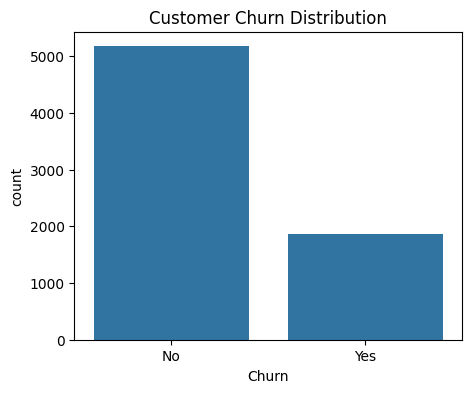

In [91]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

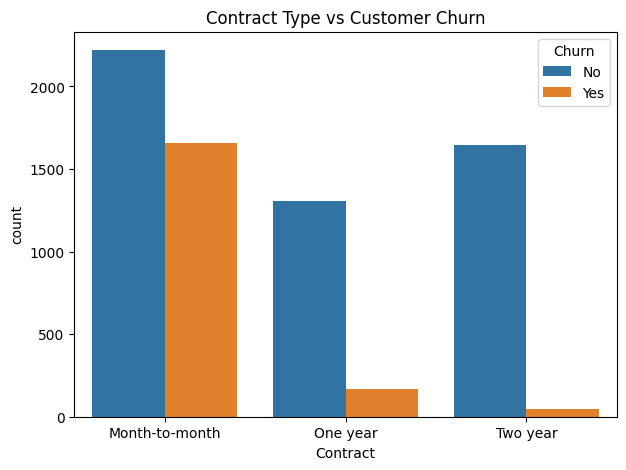

In [92]:
plt.figure(figsize=(7,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Customer Churn")
plt.show()

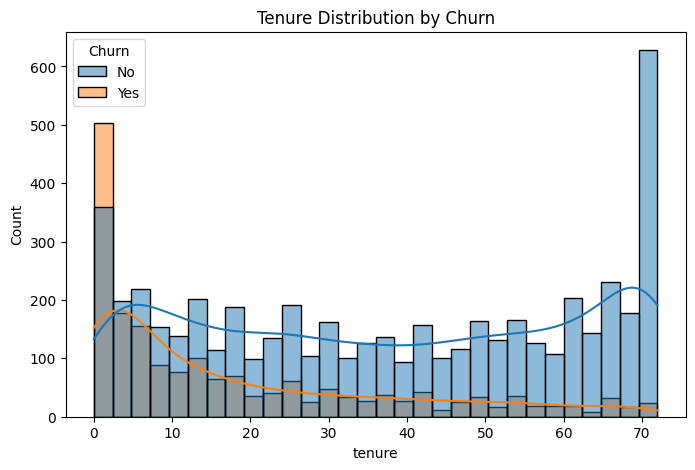

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)

plt.title("Tenure Distribution by Churn")
plt.show()

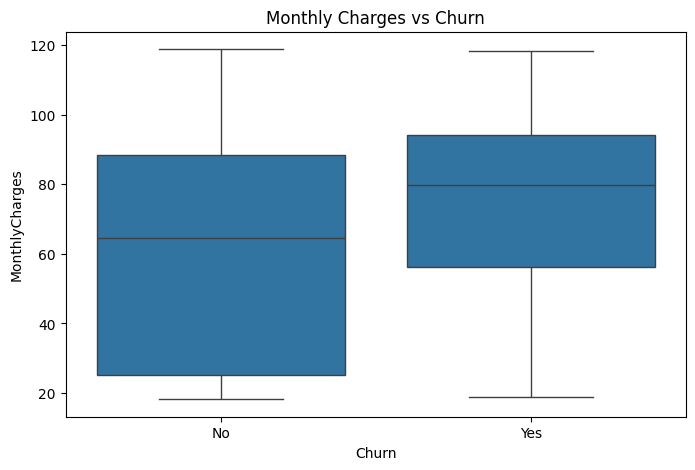

In [94]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()


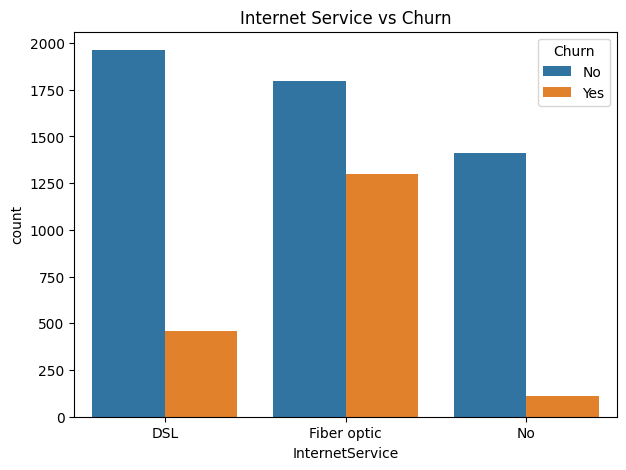

In [95]:
plt.figure(figsize=(7,5))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")
plt.show()

In [96]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [97]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [99]:
df.dropna(inplace=True)

In [100]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [102]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col} : {df[col].unique()}")
    print("-"*50)

gender : ['Female' 'Male']
--------------------------------------------------
Partner : ['Yes' 'No']
--------------------------------------------------
Dependents : ['No' 'Yes']
--------------------------------------------------
PhoneService : ['No' 'Yes']
--------------------------------------------------
MultipleLines : ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService : ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity : ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup : ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection : ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport : ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV : ['No' 'Yes' 'No internet service']
---------------------------------------

In [103]:
# ============================================
# Step 9: Encode categorical features
# Purpose:
# Convert text values into numbers so that
# machine learning algorithms can process them.
# ============================================

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode all categorical columns
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# Display first 5 rows
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

In [105]:
# ============================================
# Step 11: Separate Features (X) and Target (y)
#
# X -> Input features
# y -> Target variable (Churn)
# ============================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (7032, 19)
Target Shape   : (7032,)


In [106]:
# ============================================
# Step 12: Split dataset into Training & Testing
#
# 80% -> Train the model
# 20% -> Test the model
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (5625, 19)
Testing Data  : (1407, 19)


In [107]:
# ============================================
# Step 13: Train Logistic Regression Model
# ============================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


c:\Users\91855\OneDrive\Desktop\Customer-Churn-Prediction\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [108]:
# ============================================
# Step 13: Feature Scaling
#
# Why?
# Logistic Regression performs better when
# numerical features are on a similar scale.
# ============================================

from sklearn.preprocessing import StandardScaler

In [109]:
# ============================================
# Create StandardScaler object
# ============================================

scaler = StandardScaler()

In [110]:
# ============================================
# Learn mean & standard deviation from
# training data and scale it.
# ============================================

X_train_scaled = scaler.fit_transform(X_train)

In [111]:
# ============================================
# Scale testing data using the SAME scaler.
#
# IMPORTANT:
# Never fit on test data.
# ============================================

X_test_scaled = scaler.transform(X_test)

In [112]:
# ============================================
# Train Logistic Regression on scaled data
# ============================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [113]:
# ============================================
# Predict on test data
# ============================================

lr_pred = lr_model.predict(X_test_scaled)

In [114]:
# ============================================
# Evaluate Logistic Regression
# ============================================

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.7853589196872779


In [115]:
# ============================================
# Train Decision Tree Classifier
# ============================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [116]:
# ============================================
# Predict using Decision Tree
# ============================================

dt_pred = dt_model.predict(X_test)

In [117]:
# ============================================
# Evaluate Decision Tree
# ============================================

from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.7249466950959488


In [118]:
# ============================================
# Step 17: Train Random Forest Classifier
#
# Why?
# Random Forest combines many Decision Trees,
# reducing overfitting and improving accuracy.
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [119]:
# ============================================
# Step 18: Predict using Random Forest
# ============================================

rf_pred = rf_model.predict(X_test)

In [120]:
# ============================================
# Step 19: Evaluate Random Forest
# ============================================

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.7924662402274343


In [121]:
# ============================================
# Step 20: Compare Model Performance
# ============================================

model_results = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

model_results

{'Logistic Regression': 0.7853589196872779,
 'Decision Tree': 0.7249466950959488,
 'Random Forest': 0.7924662402274343}

In [122]:
# ============================================
# Step 21: Train XGBoost Classifier
#
# XGBoost = eXtreme Gradient Boosting
# One of the most powerful algorithms for
# structured/tabular datasets.
# ============================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [123]:
# ============================================
# Step 22: Predict using XGBoost
# ============================================

xgb_pred = xgb_model.predict(X_test)

In [124]:
# ============================================
# Step 23: Evaluate XGBoost
# ============================================

from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_accuracy)

XGBoost Accuracy : 0.7640369580668088


In [125]:
# ============================================
# Step 24: Final Model Comparison
# ============================================

model_results["XGBoost"] = xgb_accuracy

import pandas as pd

results_df = pd.DataFrame(
    model_results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
2,Random Forest,0.792466
0,Logistic Regression,0.785359
3,XGBoost,0.764037
1,Decision Tree,0.724947


SECOND TIME TRAINING THE MODEL


In [126]:
# ============================================
# STEP 1 : Load Required Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [127]:
# ============================================
# STEP 2 : Load Dataset
# ============================================

df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [128]:
# ============================================
# STEP 3 : Remove Customer ID
#
# customerID is only an identifier.
# It does not help in prediction.
# ============================================

df.drop("customerID", axis=1, inplace=True)

In [129]:
# ============================================
# STEP 4 : Convert TotalCharges to Numeric
#
# Some rows contain blank spaces.
# Convert them into NaN.
# ============================================

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)


In [130]:
# ============================================
# STEP 5 : Remove Missing Values
# ============================================

df.dropna(inplace=True)

In [131]:
# ============================================
# STEP 6 : Binary Mapping
#
# Convert binary categorical columns
# into 0 and 1.
# ============================================

binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

binary_map = {
    "Male":1,
    "Female":0,

    "Yes":1,
    "No":0
}

for col in binary_columns:
    df[col] = df[col].map(binary_map)

In [132]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   object 
 17  

In [134]:
# ============================================
# STEP 7 : Check Remaining Categorical Columns
#
# After binary mapping, these columns are
# still categorical and need encoding.
# ============================================

df.select_dtypes(include="object").columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

In [135]:
# ============================================
# STEP 8 : One-Hot Encode Nominal Features
#
# drop_first=True avoids the Dummy Variable Trap
# and reduces unnecessary columns.
# ============================================

df = pd.get_dummies(
    df,
    columns=[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],
    drop_first=True
)

In [136]:
# ============================================
# STEP 10 : Convert Boolean Columns to Integers
# ============================================

bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [137]:
# ============================================
# STEP 11 : Separate Features (X) and Target (y)
# ============================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [138]:
# ============================================
# STEP 12 : Split Dataset
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [139]:
# ============================================
# STEP 13 : Scale Numerical Features
# (Only for Logistic Regression)
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [140]:
# ============================================
# Logistic Regression
# ============================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [141]:
# ============================================
# Decision Tree
# ============================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [142]:
# ============================================
# Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [143]:
# ============================================
# XGBoost
# ============================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [144]:
# ============================================
# Compare All Models
# ============================================

from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.803838
3,XGBoost,0.791045
2,Random Forest,0.786780
1,Decision Tree,0.712864


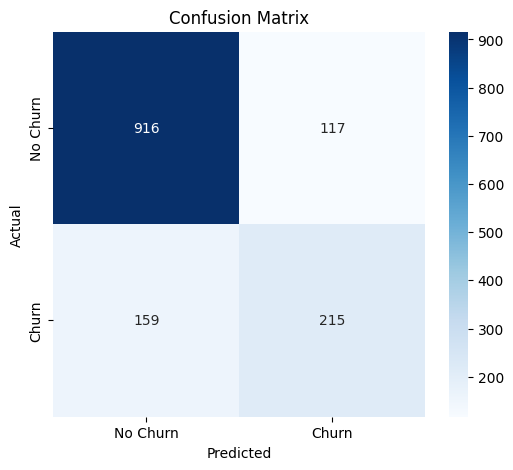

In [145]:
# ============================================
# STEP 19 : Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [146]:
# ============================================
# STEP 20 : Classification Report
# ============================================

from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [147]:
# ============================================
# STEP 22 : Save Model
# ============================================

import os
import joblib

# Create model folder if it doesn't exist
os.makedirs("../model", exist_ok=True)

# Save model
joblib.dump(lr_model, "../model/churn_model.pkl")

# Save scaler
joblib.dump(scaler, "../model/scaler.pkl")

print("✅ Model and Scaler Saved Successfully")

✅ Model and Scaler Saved Successfully


In [148]:
# ============================================
# Compare All Models using Classification Report
# ============================================

from sklearn.metrics import classification_report

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

for name, (model, test_data) in models.items():

    print("="*60)
    print(name)
    print("="*60)

    prediction = model.predict(test_data)

    print(classification_report(y_test, prediction))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Decision Tree
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1033
           1       0.46      0.45      0.46       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78   

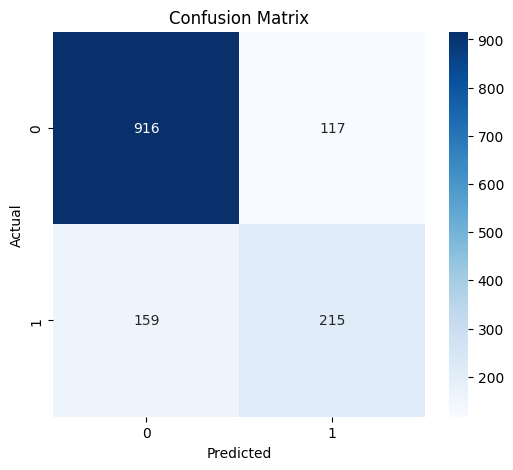

In [149]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

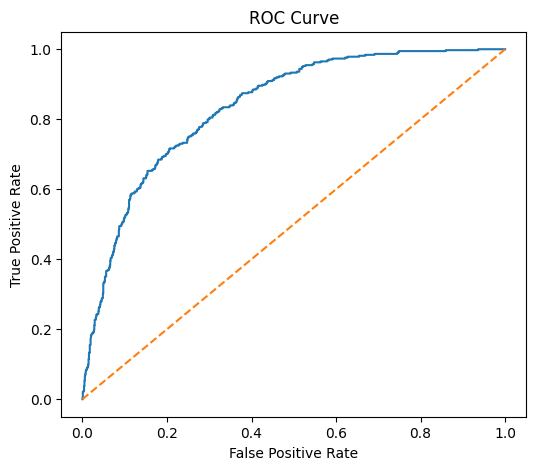

ROC AUC : 0.8356727976766699


In [150]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

probability = lr_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, threshold = roc_curve(y_test, probability)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("ROC AUC :", roc_auc_score(y_test, probability))

In [151]:
import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(lr_model, "model/churn_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

print("Saved Successfully")

Saved Successfully


THIRD TIME TRAINING MODEL

In [152]:
# ============================================
# STEP 1 : Import Libraries
# ============================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [153]:
# ============================================
# STEP 2 : Load Dataset
# ============================================

df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [154]:
# ============================================
# STEP 3 : Separate Features and Target
# ============================================

X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [155]:
# ============================================
# STEP 4 : Feature Lists
# ============================================

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [156]:
# ============================================
# STEP 5 : Create Preprocessing Pipeline
#
# Numerical Columns:
# - Fill missing values with median
# - Scale the values
#
# Categorical Columns:
# - Fill missing values with most frequent value
# - Apply One-Hot Encoding
# ============================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [157]:
# ============================================
# STEP 6 : Create Machine Learning Pipeline
#
# Pipeline =
# Preprocessing
#      ↓
# Logistic Regression
# ============================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [158]:
# ============================================
# STEP 7 : Split Dataset
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [159]:
# ============================================
# STEP 8 : Train Pipeline
# ============================================

pipeline.fit(X_train, y_train)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [160]:
# ============================================
# STEP 9 : Prediction
# ============================================

y_pred = pipeline.predict(X_test)

In [161]:
# ============================================
# STEP 10 : Evaluate Model
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

Accuracy : 0.8045486851457001

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [162]:
# ============================================
# STEP 11 : Save Pipeline
# ============================================

import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(
    pipeline,
    "../model/pipeline.pkl"
)

print("Pipeline Saved Successfully ✅")

Pipeline Saved Successfully ✅
